In [1]:
import os
import sys
# set working directory
os.chdir("../riemannian_la")
print(os.getcwd())

import torch
from matplotlib import pyplot as plt
from torch.utils.data import DataLoader, TensorDataset

from models import LinearModel, FunctionApproximatorModel
from train import train
from laplace_approx import Laplace
from MCMC_sampler import MCMC_sampler
from getdata import make_loaders, torch_seed, gen_model_data, gen_log_regression_data
from utils import NegLogLik_regression
from integration import integrator
from utils import loss_func_from_target_sigma, make_functional_fwd_xs, functional_loss, functional_loss_for_vmap, sum_loss, neglog_loss, tensify
from discrete_sampler import discrete_function_sampler, discrete_model_sampler
from riemann_sampler import Riemann_sampler, riemann_plotter
from BQ_rays_subspace import BayesianQuadrature_rays
from emukit.quadrature.methods import VanillaBayesianQuadrature, WarpedBayesianQuadratureModel, BoundedBayesianQuadrature
from emukit.quadrature.methods.warpings import SquareRootWarping
from emukit.model_wrappers import GPyModelWrapper
import numpy as np
from models import functional_banana, Model_from_func
import seaborn as sns
import pandas as pd


fig_folder = "../report/figures"
os.makedirs(fig_folder, exist_ok=True)
torch.manual_seed(0)

/Users/simondanieleiriksson/Documents/DTU-kurser-lokalt/Specialkursus Georgios/riemannian-la/riemannian_la


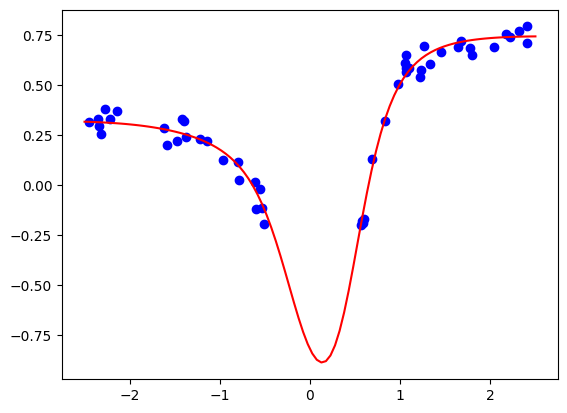

In [5]:
num_features=1
UFA_model = FunctionApproximatorModel(num_features=num_features, hidden_layers=[10,10], num_outputs=1, nonlin = torch.nn.Tanh(), seed=47)

prior_sigma = 1.
target_sigma = 0.05

start_x = -2.5
end_x = 2.5
#input_dist = lambda x: torch.rand(x, num_features)*(end_x-start_x) + start_x
def input_dist(N):
    xs = torch.rand(N*10, num_features)*(end_x-start_x) + start_x
    index = (1-((xs > -.5) & (xs < 0.5)).int()).nonzero()[:,0]
    return xs[index][:N]

train_loader, test_loader = gen_model_data(UFA_model, input_dist, num_train_samples=50, 
                                           num_test_samples=10, noise_std=target_sigma, seed=2, batch_size=1)

pre_trained_params = torch.nn.utils.parameters_to_vector(UFA_model.parameters())
xs, ys = train_loader.dataset.dataset.tensors
xs_plt = torch.linspace(start_x, end_x, 100).unsqueeze(1)
plt.scatter(xs[:, 0].detach(), ys.detach(), c="b", label="data")
ys_plt_pretrained = UFA_model(xs_plt).detach()
plt.plot(xs_plt[:, 0].detach(), ys_plt_pretrained, c="r", label="true function")
plt.show()


In [6]:
# Ok, we got some data now. 
# We already know the true mode, but because of the noise we have to post-train it, 
# to be sure that we are actually at the optimal parameters
# We do however start from the true parameters, so we should be able to get there

lr = torch.tensor(0.01)
optimizer = torch.optim.Adam(UFA_model.parameters(), lr=lr)
schedule_factor = 0.0001
epochs= 1000

scheduler = torch.optim.lr_scheduler.LinearLR(optimizer,start_factor=1, end_factor=schedule_factor, total_iters=epochs)

UFA_model, _, _, _, _ = train(UFA_model, train_loader=train_loader, test_loader=test_loader, optimizer=optimizer, 
              scheduler=scheduler, epochs=epochs, 
          prior_sigma=prior_sigma,
          target_sigma=target_sigma,
          device="cpu", logger_info=None,
          plot=False, plotpath=None, verbose = True, print_every_epoch=100)

trained_params = torch.nn.utils.parameters_to_vector(UFA_model.parameters())


epoch = 100 	train loss: 1.57245, train prediction loss: 1.30856, regularization loss: 0.26389, norm of gradient: 6312.18019, test loss: 3.82022, test accuracy: 0.00, lr: 9.000115e-03
epoch = 200 	train loss: 1.53058, train prediction loss: 1.31126, regularization loss: 0.21932, norm of gradient: 5940.75566, test loss: 3.14752, test accuracy: 0.00, lr: 8.000220e-03
epoch = 300 	train loss: 1.33555, train prediction loss: 1.13471, regularization loss: 0.20084, norm of gradient: 5051.15350, test loss: 2.98574, test accuracy: 0.00, lr: 7.000322e-03
epoch = 400 	train loss: 1.39173, train prediction loss: 1.19545, regularization loss: 0.19628, norm of gradient: 4941.92090, test loss: 2.37312, test accuracy: 0.00, lr: 6.000417e-03
epoch = 500 	train loss: 1.26717, train prediction loss: 1.07778, regularization loss: 0.18939, norm of gradient: 3732.10869, test loss: 2.11970, test accuracy: 0.00, lr: 5.000509e-03
epoch = 600 	train loss: 1.10281, train prediction loss: 0.91974, regularization

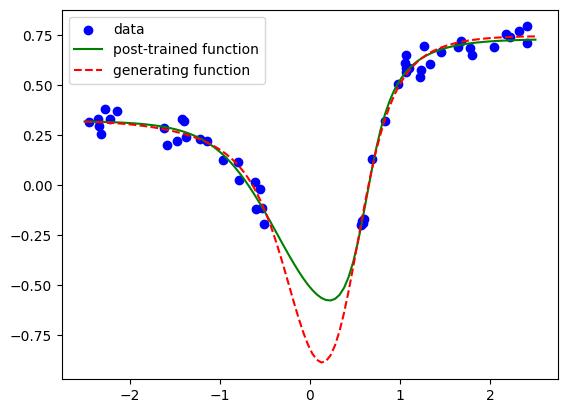

In [7]:
plt.scatter(xs[:, 0].detach(), ys.detach(), c="b", label="data")
ys_plt_trained = UFA_model(xs_plt).detach()
plt.plot(xs_plt[:, 0].detach(), ys_plt_trained, c="g", label="post-trained function")
plt.plot(xs_plt[:, 0].detach(), ys_plt_pretrained, label="generating function", linestyle="--", c="r")
plt.legend()
plt.savefig(f"{fig_folder}/post_trained_function.png")

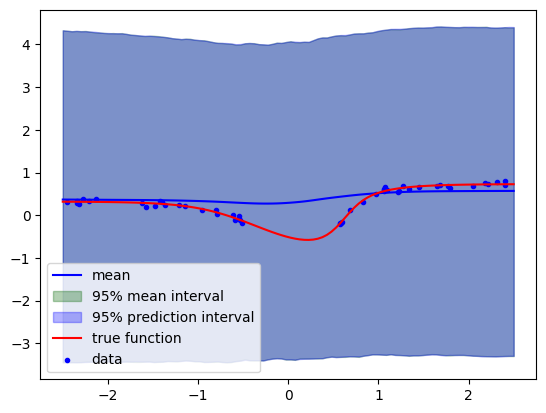

In [8]:
####################################
# Ok, we have trained the model. Now we can try to fit a Laplace approximation to the posterior
####################################
loss_fn = NegLogLik_regression(target_sigma=target_sigma)
laplace = Laplace(UFA_model, xs=xs, ys=ys, prior_sigma=prior_sigma, loss_fn=loss_fn, subspace_rank=0)

_=laplace.fit_subspace(fitting_type="GGN", xs=xs, ys=ys)
#_=laplace.fit(fitting_type="GGN", xs=xs, ys=ys)
#print(f"Covariance: {laplace.covariance}")
#print(f"Mean: {laplace.mean}")

laplace.make_posterior_sample(n_samples=10000)

integral_la, function_values_la, weights_la, posterior_samples_la = integrator(sampler=laplace, model_func=make_functional_fwd_xs(UFA_model), xs=xs_plt)

means = integral_la.detach()[:, 0]
means_la = function_values_la.mean(dim=0).detach()
upper95_api_la = function_values_la.quantile(.95, dim=0).detach()
lower95_epi_la = function_values_la.quantile(.05, dim=0).detach()
pred_samples = (torch.distributions.Normal(function_values_la, target_sigma).sample((10,)))
upper95_both_la = (pred_samples.reshape(pred_samples.shape[0] * pred_samples.shape[1], *pred_samples.shape[2:])).quantile(.95, dim=0).detach()
lower95_both_la = (pred_samples.reshape(pred_samples.shape[0] * pred_samples.shape[1], *pred_samples.shape[2:])).quantile(.05, dim=0).detach()

plt.plot(xs_plt, means_la, c="blue", label="mean")
plt.fill_between(xs_plt[:,0], lower95_epi_la[:,0], upper95_api_la[:,0], alpha=0.3, color="darkgreen", label="95% mean interval")
plt.fill_between(xs_plt[:,0], lower95_both_la[:,0], upper95_both_la[:,0], alpha=0.3, color="blue", label="95% prediction interval")
plt.plot(xs_plt[:, 0].detach(), ys_plt_trained, c="red", label="true function")
plt.scatter(xs[:, 0].detach(), ys.detach(), c="blue", marker=".", label="data")
plt.legend()
plt.savefig(f"{fig_folder}/laplace_approximation_fullrank.png")
plt.show()




# epistemic_var = (function_values_lp[:,:, 0]-means.unsqueeze(0)).pow(2).mean(dim=0).detach()
# aleatoric_var = target_sigma**2
# plt.plot(xs_plt, means, c="g", label="mean")
# plt.fill_between(xs_plt[:,0], means - np.sqrt(aleatoric_var + epistemic_var), means + np.sqrt(aleatoric_var + epistemic_var), alpha=0.3, color="darkgreen", label="epistemic + aleatoric")
# plt.fill_between(xs_plt[:,0], means - np.sqrt(epistemic_var), means + np.sqrt(epistemic_var), alpha=0.3, color="blue", label="epistemic")
# plt.plot(xs_plt[:, 0].detach(), ys_plt_trained, c="r", label="true function")
# plt.scatter(xs[:, 0].detach(), ys.detach(), c="b", marker=".", label="data")
# plt.legend()
# plt.savefig(f"{fig_folder}/laplace_approximation_fullrank.png")
# plt.show()


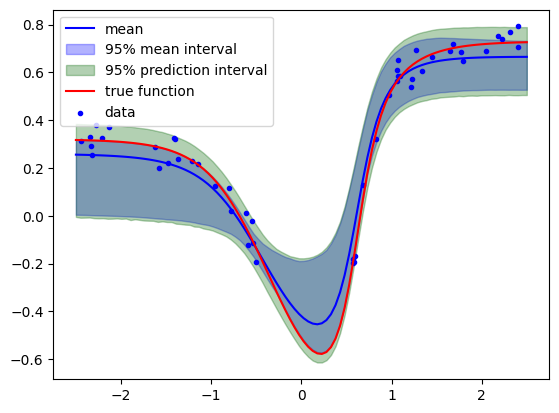

In [9]:
####################################
# Laplace subspace integration
####################################
loss_fn = NegLogLik_regression(target_sigma=target_sigma)
laplace = Laplace(UFA_model, xs=xs, ys=ys, prior_sigma=prior_sigma, loss_fn=loss_fn, n_posterior_samples=100, subspace_rank=2)

_=laplace.fit(fitting_type="GGN", xs=xs, ys=ys)
#print(f"Covariance: {laplace.covariance}")
#print(f"Mean: {laplace.mean}")

laplace.make_posterior_sample(n_samples=10000)
integral_la, function_values_la, weights_la, posterior_samples_la = integrator(sampler=laplace, model_func=make_functional_fwd_xs(UFA_model), xs=xs_plt)

means = integral_la.detach()[:, 0]
means_la = function_values_la.mean(dim=0).detach()
upper95_api_la = function_values_la.quantile(.95, dim=0).detach()
lower95_epi_la = function_values_la.quantile(.05, dim=0).detach()
pred_samples = (torch.distributions.Normal(function_values_la, target_sigma).sample((10,)))
upper95_both_la = (pred_samples.reshape(pred_samples.shape[0] * pred_samples.shape[1], *pred_samples.shape[2:])).quantile(.95, dim=0).detach()
lower95_both_la = (pred_samples.reshape(pred_samples.shape[0] * pred_samples.shape[1], *pred_samples.shape[2:])).quantile(.05, dim=0).detach()

plt.plot(xs_plt, means_la, c="blue", label="mean")
plt.fill_between(xs_plt[:,0], lower95_epi_la[:,0], upper95_api_la[:,0], alpha=0.3, color="blue", label="95% mean interval")
plt.fill_between(xs_plt[:,0], lower95_both_la[:,0], upper95_both_la[:,0], alpha=0.3, color="darkgreen", label="95% prediction interval")
plt.plot(xs_plt[:, 0].detach(), ys_plt_trained, c="r", label="true function")
plt.scatter(xs[:, 0].detach(), ys.detach(), c="blue", marker=".", label="data")
plt.legend()
plt.savefig(f"{fig_folder}/laplace_approximation_subspace_rank2.png")
plt.show()



# means = integral_la.detach()[:, 0]
# epistemic_var = (function_values_la[:,:, 0]-means.unsqueeze(0)).pow(2).mean(dim=0).detach()
# aleatoric_var = target_sigma**2
# plt.scatter(xs[:, 0].detach(), ys.detach(), c="b", marker=".", label="data")
# plt.plot(xs_plt[:, 0].detach(), means)
# plt.fill_between(xs_plt[:,0], means - np.sqrt(aleatoric_var + epistemic_var), means + np.sqrt(aleatoric_var + epistemic_var), alpha=0.3, color="darkgreen", label="epistemic + aleatoric")
# plt.fill_between(xs_plt[:,0], means - np.sqrt(epistemic_var), means + np.sqrt(epistemic_var), alpha=0.3, color="blue", label="epistemic")
# plt.plot(xs_plt[:, 0].detach(), ys_plt_trained, c="r", label="true function")
# plt.legend()
# plt.savefig(f"{fig_folder}/laplace_approximation_subspace_rank1.png")
# plt.show()

# plt.plot(xs_plt, np.sqrt(aleatoric_var + epistemic_var))
# plt.plot(xs_plt, np.sqrt(epistemic_var))
# plt.show()

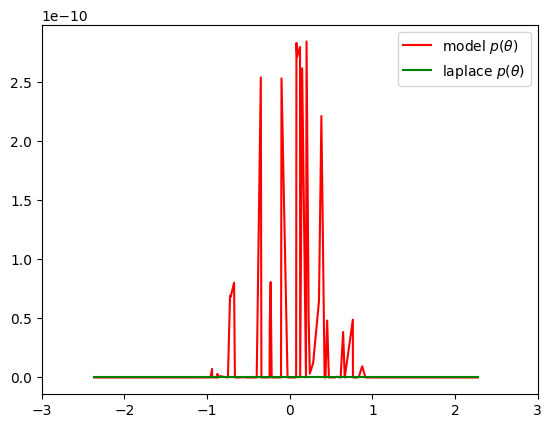

In [12]:
_, function_values_eval, weights_eval, posterior_samples_eval = integrator(sampler=laplace, model_func=make_functional_fwd_xs(UFA_model), xs=xs)

err = (function_values_eval[:,:, :]-ys).pow(2).sum(dim=[1,2])
log_prob = -err/(2 * tensify(target_sigma)**2) - ys.shape[0] * .5 * tensify(target_sigma) * torch.log(torch.tensor(2 * torch.pi)) 
val, ind = laplace.eps[:, 0][0:100].sort()
reg = log_prob[(laplace.eps[:, 0]**2).argmin()]
lp = torch.distributions.Normal(0,1).log_prob(laplace.eps[:, 0]) + reg - torch.distributions.Normal(0,1).log_prob(torch.tensor(0.0)) 
plt.plot(val.detach(), log_prob.exp()[ind].detach(), label="model $p(\\theta)$", c="r")
plt.plot(val.detach(), lp.exp()[ind].detach(), label="laplace $p(\\theta)$", c="g")
plt.legend()
plt.xlim(-3, 3)
#plt.savefig(os.path.join(fig_folder, "UFA_laplace_prob.png"))
plt.show()

In [31]:
val

tensor([-3.6582, -3.5273, -3.4234,  ...,  3.3347,  3.4083,  3.7741])

In [8]:
torch.manual_seed(0)
R_sampler = Riemann_sampler(UFA_model, xs=xs, ys=ys, loss_fn=loss_fn, prior_sigma=prior_sigma,  
                            n_posterior_samples=10, subspace_rank=2)
R_sampler.fit(fitting_type="GGN")
_=R_sampler.make_posterior_sample(n_samples=10)



In [9]:
integral_riemann, function_values_riemann, weights_riemann, posterior_samples_riemann = integrator(R_sampler, model_func=make_functional_fwd_xs(UFA_model), xs=xs_plt)

means_riemann = function_values_riemann.mean(dim=0).detach()
upper95_riemann = function_values_riemann.quantile(.95, dim=0).detach()
lower95_riemann = function_values_riemann.quantile(.05, dim=0).detach()
pred_samples_riemann = (torch.distributions.Normal(function_values_riemann, target_sigma).sample((1000,)))
upper95_both_riemann = (pred_samples_riemann.reshape(pred_samples_riemann.shape[0] * pred_samples_riemann.shape[1], *pred_samples_riemann.shape[2:])).quantile(.95, dim=0).detach()
lower95_both_riemann = (pred_samples_riemann.reshape(pred_samples_riemann.shape[0] * pred_samples_riemann.shape[1], *pred_samples_riemann.shape[2:])).quantile(.05, dim=0).detach()


plt.plot(xs_plt, means_riemann, c="blue", label="mean")
plt.fill_between(xs_plt[:,0], lower95_riemann[:,0], upper95_riemann[:,0], alpha=0.3, color="blue", label="95% mean interval")
plt.fill_between(xs_plt[:,0], lower95_both_riemann[:,0], upper95_both_riemann[:,0], alpha=0.3, color="darkgreen", label="95% prediction interval")
plt.plot(xs_plt[:, 0].detach(), ys_plt_trained, c="r", label="true function")
plt.scatter(xs[:, 0].detach(), ys.detach(), c="b", marker=".", label="data")
plt.legend()
plt.savefig(f"{fig_folder}/UFA_riemannian_subspace_rank2.png")
plt.show()

# means = integral_riemann.detach()[:, 0]
# epistemic_var = (function_values_riemann[:,:, 0]-means.unsqueeze(0)).pow(2).mean(dim=0).detach()
# aleatoric_var = target_sigma**2
# plt.plot(xs_plt, means, c="darkgreen", label="mean")
# plt.fill_between(xs_plt[:,0], means - np.sqrt(aleatoric_var + epistemic_var), means + np.sqrt(aleatoric_var + epistemic_var), alpha=0.3, color="blue", label="epistemic + aleatoric")
# plt.fill_between(xs_plt[:,0], means - np.sqrt(epistemic_var), means + np.sqrt(epistemic_var), alpha=0.3, color="darkgreen", label="epistemic")
# plt.plot(xs_plt[:, 0].detach(), ys_plt_trained, c="r", label="true function")
# plt.scatter(xs[:, 0].detach(), ys.detach(), c="b", marker=".", label="data")
# plt.legend()
# plt.savefig(os.path.join(fig_folder, "UFA_riemannian_subspace_rank1.png"))
# plt.show()

In [10]:
%%script echo
torch.manual_seed(0)
R_sampler = Riemann_sampler(UFA_model, xs=xs, ys=ys, loss_fn=loss_fn, prior_sigma=prior_sigma,  
                            n_posterior_samples=10, subspace_rank=0)
R_sampler.fit(fitting_type="GGN")
R_sampler.make_posterior_sample(n_samples=10)
#riemann_plotter(R_sampler)

integral, function_values, weights, posterior_samples = integrator(R_sampler, model_func=make_functional_fwd_xs(UFA_model), xs=xs_plt)

means = integral.detach()[:, 0]
epistemic_var = (function_values[:,:, 0]-means.unsqueeze(0)).pow(2).mean(dim=0).detach()
aleatoric_var = target_sigma**2
plt.plot(xs_plt, means, c="g", label="mean")
plt.fill_between(xs_plt[:,0], means - np.sqrt(aleatoric_var + epistemic_var), means + np.sqrt(aleatoric_var + epistemic_var), alpha=0.3, color="darkgreen", label="epistemic + aleatoric")
plt.fill_between(xs_plt[:,0], means - np.sqrt(epistemic_var), means + np.sqrt(epistemic_var), alpha=0.3, color="blue", label="epistemic")
plt.plot(xs_plt[:, 0].detach(), ys_plt_trained, c="r", label="true function")
plt.scatter(xs[:, 0].detach(), ys.detach(), c="b", marker=".", label="data")
plt.legend()
plt.savefig(os.path.join(fig_folder, "UFA_riemannian_subspace_rank1.png"))
plt.show()

In [55]:
####################################
# Bayesian Quadrature integration
####################################

R_sampler_1d = Riemann_sampler(UFA_model, xs=xs, ys=ys, loss_fn=loss_fn, prior_sigma=prior_sigma, subspace_rank=1)
_=R_sampler_1d.fit(fitting_type="GGN")

BQ_1d = BayesianQuadrature_rays(R_sampler_1d, evaluation_model=UFA_model, measure="gaussian_rescaled", integral_bounds_std=4, 
                             GP_lengthscale=1.0, GP_variance=1.0, num_timesteps=7, use_ray_acqusition=False,  
                             use_rays=False, 
                             theta_space_plot_limits=[[-1,1], [-1,1]], xs = xs[0], parametersubset=None)

for i in range(2):
    integral_mean, integral_variance = BQ_1d.step()
    print(f"{i = }, observations = {BQ_1d.emukit_method.X.shape[0]}, {integral_mean = }, {integral_variance = }")


i = 0, observations = 2, integral_mean = tensor([0.5276]), integral_variance = tensor(0.0436)
i = 1, observations = 3, integral_mean = tensor([0.6086]), integral_variance = tensor(0.0025)


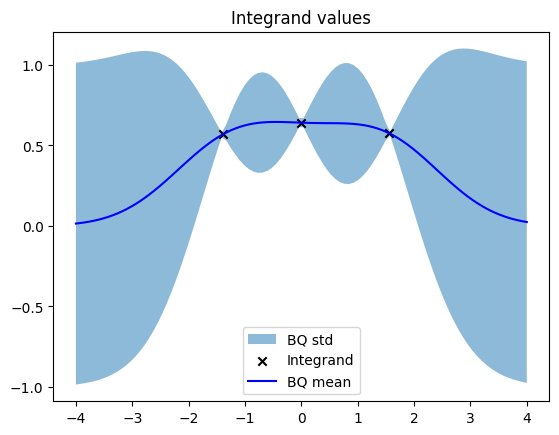

 /Users/simondanieleiriksson/Documents/DTU-kurser-lokalt/Specialkursus Georgios/riemannian-la/riemannian_la/BQ_rays_subspace.py:504: UserWarning:To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).


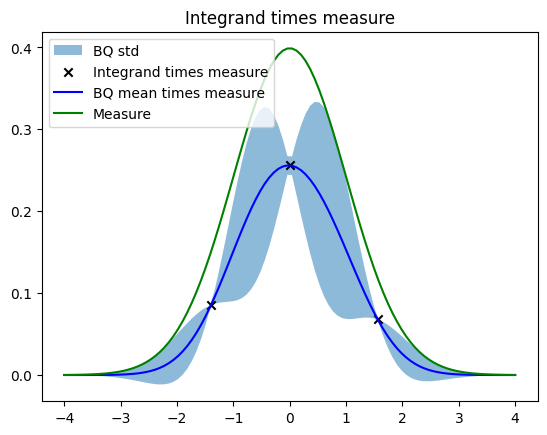

In [56]:
# fig, axes = plt.subplots(1,2, figsize=(10,5))
# BQ.plot_integrand_1d(ax=axes[0])
# BQ.plot_integrand_measure_1d(ax=axes[1])
# plt.savefig(os.path.join(fig_folder, "UFA_BQ_integrand_1d.png"))
# plt.show()
fig, ax = plt.subplots(1,1)
BQ_1d.plot_integrand_1d(ax=ax)
plt.savefig(os.path.join(fig_folder, "UFA_BQ_integrand_vals_1d.png"))
plt.show()

fig, ax = plt.subplots(1,1)
BQ_1d.plot_integrand_measure_1d(ax=ax)
plt.savefig(os.path.join(fig_folder, "UFA_BQ_integrand_vals_measure_1d.png"))
plt.show()


i = 0, observations = 2, integral_mean = tensor([0.5276]), integral_variance = tensor(0.0436)
i = 1, observations = 3, integral_mean = tensor([0.6086]), integral_variance = tensor(0.0025)
i = 2, observations = 4, integral_mean = tensor([0.6038]), integral_variance = tensor(0.0009)
i = 3, observations = 5, integral_mean = tensor([0.5997]), integral_variance = tensor(0.0005)
i = 4, observations = 6, integral_mean = tensor([0.6038]), integral_variance = tensor(0.0002)


In [61]:
BQ_2d.plot()

i = 0, observations = 7, integral_mean = tensor([0.4076]), integral_variance = tensor(0.0499)
i = 1, observations = 13, integral_mean = tensor([0.5197]), integral_variance = tensor(0.0166)
i = 2, observations = 19, integral_mean = tensor([0.6020]), integral_variance = tensor(0.0111)
i = 3, observations = 25, integral_mean = tensor([0.6027]), integral_variance = tensor(0.0060)
i = 4, observations = 31, integral_mean = tensor([0.6033]), integral_variance = tensor(0.0043)
i = 5, observations = 37, integral_mean = tensor([0.6089]), integral_variance = tensor(0.0016)
i = 6, observations = 43, integral_mean = tensor([0.6264]), integral_variance = tensor(0.0009)
i = 7, observations = 49, integral_mean = tensor([0.6553]), integral_variance = tensor(0.0001)
i = 8, observations = 55, integral_mean = tensor([0.6519]), integral_variance = tensor(8.2473e-05)


 /Users/simondanieleiriksson/Documents/DTU-kurser-lokalt/Specialkursus Georgios/riemannian-la/riemannian_la/BQ_rays_subspace.py:398: UserWarning:To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
 /Users/simondanieleiriksson/Documents/DTU-kurser-lokalt/Specialkursus Georgios/riemannian-la/.venv/lib/python3.12/site-packages/GPy/core/gp.py:285: SyntaxWarning:invalid escape sequence '\m'
 /Users/simondanieleiriksson/Documents/DTU-kurser-lokalt/Specialkursus Georgios/riemannian-la/.venv/lib/python3.12/site-packages/GPy/core/gp.py:291: SyntaxWarning:invalid escape sequence '\i'
 /Users/simondanieleiriksson/Documents/DTU-kurser-lokalt/Specialkursus Georgios/riemannian-la/.venv/lib/python3.12/site-packages/GPy/core/gp.py:701: SyntaxWarning:invalid escape sequence '\m'
 /Users/simondanieleiriksson/Documents/DTU-kurser-lokalt/Specialkursus Georgios/riemannian-la/.v

KeyboardInterrupt: 

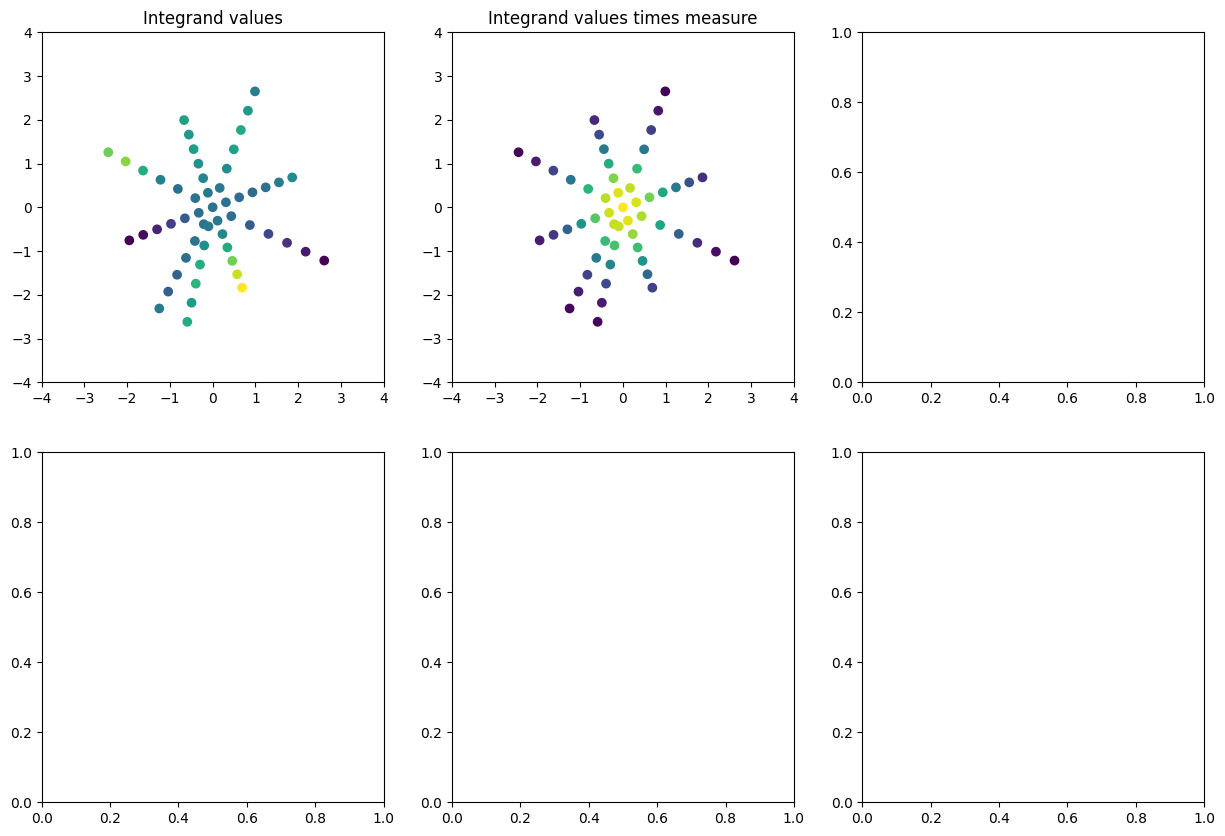

In [57]:
R_sampler_2d = Riemann_sampler(UFA_model, xs=xs, ys=ys, loss_fn=loss_fn, prior_sigma=prior_sigma, subspace_rank=2)
_=R_sampler_2d.fit(fitting_type="GGN")

BQ_2d = BayesianQuadrature_rays(R_sampler_2d, evaluation_model=UFA_model, measure="gaussian_rescaled", integral_bounds_std=4, 
                             GP_lengthscale=1.0, GP_variance=1.0, num_timesteps=7, use_ray_acqusition=True,  
                             use_rays=True, 
                             theta_space_plot_limits=[[-1,1], [-1,1]], xs = xs[0], parametersubset=None)

for i in range(16):
    integral_mean, integral_variance = BQ_2d.step()
    print(f"{i = }, observations = {BQ_2d.emukit_method.X.shape[0]}, {integral_mean = }, {integral_variance = }")
    if i == 8:
        fig, axes = BQ_2d.plot()
        plt.savefig(os.path.join(fig_folder, "UFA_BQ_integrand_2d.png"))
        plt.show()


In [ ]:
BQ_samp_trans = torch.tensor(BQ_2d.pred_BQ_samples(xs_plt, 1000)).permute(1,0,-1)
BQ_samp_trans_mean = BQ_samp_trans.mean(dim=1)
upper95_riemann_BQ = BQ_samp_trans.quantile(.95, dim=0)
lower95_riemann_BQ = BQ_samp_trans.quantile(.05, dim=0)
pred_samples_riemann_BQ = (torch.distributions.Normal(BQ_samp_trans, target_sigma).sample((117,)))
upper95_both_riemann_BQ = (pred_samples_riemann_BQ.reshape(pred_samples_riemann_BQ.shape[0] * pred_samples_riemann_BQ.shape[1], *pred_samples_riemann_BQ.shape[2:])).quantile(.95, dim=0).detach()
lower95_both_riemann_BQ = (pred_samples_riemann_BQ.reshape(pred_samples_riemann_BQ.shape[0] * pred_samples_riemann_BQ.shape[1], *pred_samples_riemann_BQ.shape[2:])).quantile(.05, dim=0).detach()



In [ ]:

plt.plot(xs_plt, means_riemann, c="blue", label="mean")
plt.fill_between(xs_plt[:,0], lower95_riemann_BQ[:,0], upper95_riemann_BQ[:,0], alpha=0.3, color="blue", label="95% mean interval")
plt.fill_between(xs_plt[:,0], lower95_both_riemann_BQ[:,0], upper95_both_riemann_BQ[:,0], alpha=0.3, color="darkgreen", label="95% prediction interval")
plt.plot(xs_plt[:, 0].detach(), ys_plt_trained, c="r", label="true function")
plt.scatter(xs[:, 0].detach(), ys.detach(), c="b", marker=".", label="data")
plt.legend()
plt.savefig(f"{fig_folder}/UFA_riemannian_subspace_rank2.png")
plt.show()

#means, epistemic_var, vars = BQ_2d.pred_BQ(xs_plt, get_measure_variance=True, transform_type="identity")
#plt.scatter(xs_plt.unsqueeze(1).repeat([1, preds.shape[1], 1]), preds, marker="x", c="y", label="second central moment")
#plt.scatter(xs_plt, second_central_moments_mus - first_central_moments_mus**2, marker="x", c="g", label="first central moment")
# fig, ax = plt.subplots(1,1)

# ax.plot(xs_plt, means, c="g", label="mean")
# ax.fill_between(xs_plt[:,0], means - np.sqrt(aleatoric_var + epistemic_var), means + np.sqrt(aleatoric_var + epistemic_var), alpha=0.3, color="darkgreen", label="epistemic + aleatoric")
# ax.fill_between(xs_plt[:,0], means - np.sqrt(epistemic_var), means + np.sqrt(epistemic_var), alpha=0.3, color="blue", label="epistemic")
# ax.plot(xs_plt[:, 0].detach(), ys_plt_trained, c="r", label="true function")
# ax.scatter(xs[:, 0].detach(), ys.detach(), c="b", marker=".", label="data")
# ax.legend()x
# plt.savefig(os.path.join(fig_folder, "UFA_BQ_variance.png"))
# plt.show()

# plt.plot(xs_plt, np.sqrt(aleatoric_var + epistemic_var))
# plt.plot(xs_plt, np.sqrt(epistemic_var))
# plt.show()



## Banana distribution

In [ ]:
# make contour plot of banana function

span = 4
limits = [[-span, span], [-span, span]]
n_mesh = 100
curvature = 0.25

banana_function = functional_banana(curvature=curvature, sigma_x=2.0, sigma_y=.5)
banana_model = Model_from_func(banana_function, input_shape=[2])
parametersubset = dict(banana_model.named_parameters())
x = torch.tensor([0.0, 0.0])
print(f"{banana_function(x) = }")
torch.nn.utils.vector_to_parameters(torch.tensor([0.0, 0.0]), banana_model.parameters())
print(f"{banana_model(x) = }")

xs_banana = torch.tensor([0.0, 0.0]).unsqueeze(0)
ys_banana = banana_function(xs_banana[0]).unsqueeze(0)

class tiny_ridiculess_model_class(torch.nn.Module):
    def __init__(self, n_params):
        super().__init__()
        self.params = torch.nn.Parameter(torch.arange(n_params).float())
    def forward(self, x):
        #return torch.sin(self.params*3.1).sum().repeat(x.shape[0], 1)**2
        #return torch.ones(x.shape[0], 1)
        return self.params.sum().repeat(x.shape[0], 1)**2
        #return self.params.sum().repeat(x.shape[0], 1)+2
        
evaluation_model = tiny_ridiculess_model_class(n_params=2)
functional_evaluation_model = make_functional_fwd_xs(evaluation_model)  # make functional version of model



When using discrete integration over bnana MODEL we get integral = tensor([[4.3245]])


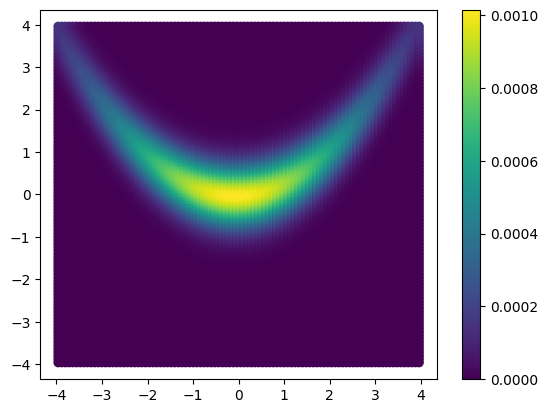

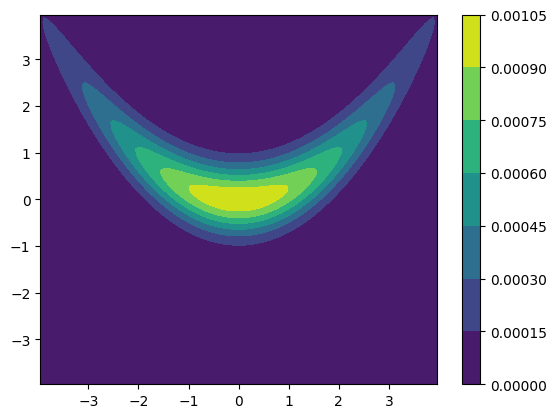

In [63]:
discrete_sampler = discrete_model_sampler(banana_model, loss_fn=neglog_loss(), xs=xs_banana, ys=ys_banana, limits=[[-span, span], [-span, span]], n_mesh=n_mesh, normalize_weights=False, prior_sigma=0.0)
posterior_samples, weights = discrete_sampler.samples_and_weights()
integral, function_values, weights, posterior_samples = integrator(discrete_sampler, functional_evaluation_model, parametersubset, xs_banana)
print(f"When using discrete integration over bnana MODEL we get {integral = }")
plt.scatter(posterior_samples[:,0], posterior_samples[:,1], c=weights)
plt.colorbar()
plt.savefig(f"{fig_folder}/banana_distr_discrete.png")
plt.show()

plt.contourf(posterior_samples[:,0].reshape(n_mesh, n_mesh).detach().numpy(), 
             posterior_samples[:,1].reshape(n_mesh, n_mesh).detach().numpy(), 
             weights.reshape(n_mesh, n_mesh).detach().numpy())
plt.colorbar()

plt.savefig(f"{fig_folder}/banana_distr_contour.png")


In [65]:
const_prior = lambda params: torch.tensor(0.0)
loss_fn = neglog_loss()

R_sampler = Riemann_sampler(banana_model, parametersubset, xs=xs_banana, ys=ys_banana, loss_fn=loss_fn, prior_loss=const_prior)
R_sampler.fit(fitting_type="hessian")

R_params=R_sampler.make_posterior_sample(50)


In [ ]:
def riemann_plotter(R_sampler, sample_markers=".", plot_traject=True, plot_traj_marker=".", max_samples=None, LA_arrows=[], kde=True, fig=None, ax=None):
    if fig is None:
        fig, ax = plt.subplots()
    cmap = plt.get_cmap("gist_rainbow")
    if plot_traject is True: plot_traject = range(len(R_sampler.trajectories))
    else: plot_traject=[]
    if LA_arrows is True: LA_arrows = range(len(R_sampler.trajectories))
    else: LA_arrows=[]
    if max_samples is None:
        max_samples = len(R_sampler.trajectories)
    if kde:
        df = pd.DataFrame(R_sampler.posterior_samples[:max_samples].numpy(), columns=["x", "y"])
        sns.kdeplot(data=df, x="x", y="y", fill=True, levels=10, color="black", ax=ax)
    if sample_markers is not None:
        ax.scatter(R_sampler.posterior_samples[:max_samples, 0], R_sampler.posterior_samples[:max_samples, 1], c="black")
    for i, sample in enumerate(R_sampler.trajectories[:max_samples]):
        color_no = (i*cmap.N)//len(R_sampler.trajectories[:max_samples])
        if (i in plot_traject) or (plot_traject is True):
            ax.plot(sample[0], sample[1], marker=plot_traj_marker, c=cmap(color_no), linewidth=1)
        if (i in LA_arrows) or (LA_arrows is True):
            dx = R_sampler.posterior_samples_la[i][0] - R_sampler.mean[0]
            dy = R_sampler.posterior_samples_la[i][1] - R_sampler.mean[1]
            ax.arrow(R_sampler.mean[0].detach(), R_sampler.mean[1].detach(), dx.detach(), dy.detach(), head_width=0.1, head_length=0.1, color=cmap(color_no))
    return fig, ax

fig, ax = plt.subplots()
ax.contourf(posterior_samples[:,0].reshape(n_mesh, n_mesh).detach().numpy(), 
             posterior_samples[:,1].reshape(n_mesh, n_mesh).detach().numpy(), 
             weights.reshape(n_mesh, n_mesh).detach().numpy())
fig, ax = riemann_plotter(R_sampler, sample_markers=".", plot_traject=True, plot_traj_marker=None, max_samples=None, LA_arrows=[1], kde=False, fig=fig, ax=ax)
ax.set_xlim(-span, span)
ax.set_ylim(-span, span)
plt.savefig(f"{fig_folder}/banana_distr_contour_riemannshots.png")

plt.show()

In [ ]:
discrete_sampler = discrete_model_sampler(banana_model, loss_fn=neglog_loss(), xs=xs_banana, ys=ys_banana, limits=[[-span, span], [-span, span]], n_mesh=n_mesh, normalize_weights=False, prior_sigma=0.0)
posterior_samples, weights = discrete_sampler.samples_and_weights()
integral, function_values, weights, posterior_samples = integrator(discrete_sampler, functional_evaluation_model, parametersubset, xs_banana)

fig, ax = plt.subplots()
ax.contourf(posterior_samples[:,0].reshape(n_mesh, n_mesh).detach().numpy(), 
             posterior_samples[:,1].reshape(n_mesh, n_mesh).detach().numpy(), 
             weights.reshape(n_mesh, n_mesh).detach().numpy())

eigvals, eigvecs = torch.linalg.eig(R_sampler.covariance)
eigvals = eigvals.real
eigvecs = eigvecs.real
angle = torch.atan(eigvecs[1,0] / eigvecs[0,0])
angle = angle * 180 / 3.14159
for i in range(10):
    ellipse = plt.matplotlib.patches.Ellipse((R_sampler.mean[0].detach(), R_sampler.mean[1].detach()), width=i*eigvals[0].sqrt().detach()*2, height=i*eigvals[1].sqrt().detach()*2, angle=angle, edgecolor="red", facecolor="none")
    ax.add_patch(ellipse)
ax.scatter(R_sampler.posterior_samples_la[:, 0].detach(), R_sampler.posterior_samples_la[:, 1].detach(), c="black")

ax.set_xlim(-span, span)
ax.set_ylim(-span, span)
plt.savefig(f"{fig_folder}/banana_distr_contour_laplace.png")

In [69]:
ys_banana

tensor([[0.1592]])

BQ_2d.steps = 1, observations = 7, integral_mean_BQ = tensor([0.3742]), integral_variance_BQ = tensor(0.0104)
BQ_2d.steps = 2, observations = 13, integral_mean_BQ = tensor([0.2795]), integral_variance_BQ = tensor(1.6391e-06)


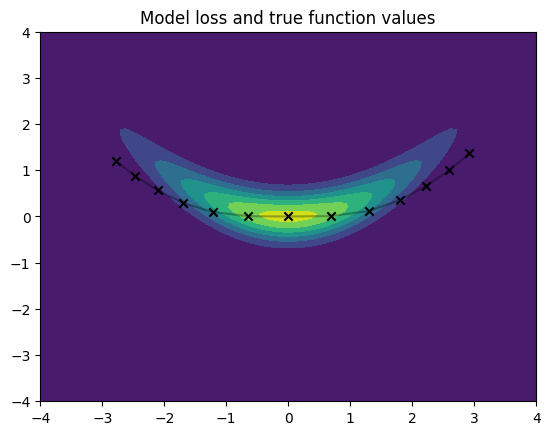

In [5]:

n_mesh = 200
curvature = 0.25
span = 20
plot_xlim=(-4,4)
plot_ylim=(-1,4)


banana_function = functional_banana(curvature=curvature, sigma_x=2.0, sigma_y=.5)
xs = torch.tensor([0.0, 0.0]).unsqueeze(0)
ys = banana_function(xs[0]).unsqueeze(0)
class tiny_ridiculess_model_class(torch.nn.Module):
    def __init__(self, n_params):
        super().__init__()
        self.params = torch.nn.Parameter(torch.arange(n_params).float())
    def forward(self, x):
        #return torch.sin(self.params*3.1).sum().repeat(x.shape[0], 1)**2
        #return torch.ones(x.shape[0], 1)
        #return self.params.sum().repeat(x.shape[0], 1)**2
        return self.params.sum().repeat(x.shape[0], 1)

const_prior = lambda x: torch.tensor(0.0)


evaluation_model = tiny_ridiculess_model_class(n_params=2)
functional_evaluation_model = make_functional_fwd_xs(evaluation_model)  # make functional version of model
limits = [[-span, span], [-span, span]]

banana_function_ = lambda x: banana_function(x)
banana_model = Model_from_func(banana_function_, input_shape=[2])
parametersubset = dict(banana_model.named_parameters())
x = torch.tensor([0.0, 0.0])
#print(f"{banana_function(x) = }")
torch.nn.utils.vector_to_parameters(torch.tensor([0.0, 0.0]), banana_model.parameters())
#print(f"{banana_model(x) = }")

xs = torch.tensor([0.0, 0.0]).unsqueeze(0)
ys = banana_function_(xs[0]).unsqueeze(0)

####################################
# 6) Bayesian Quadrature - Riemannian laplace integration over model
####################################
R_sampler_2d = Riemann_sampler(banana_model, xs=xs, ys=ys, loss_fn=neglog_loss(), prior_loss=const_prior, subspace_rank=1)
_=R_sampler_2d.fit(fitting_type="hessian")

BQ_2d = BayesianQuadrature_rays(R_sampler_2d, evaluation_model=evaluation_model, measure="gaussian_rescaled", integral_bounds_std=4, 
                             GP_lengthscale=1.0, GP_variance=1.0, num_timesteps=7, use_ray_acqusition=True,  
                             use_rays=True, 
                             theta_space_plot_limits=[[-2,2], [-2,2]], xs = xs[0], parametersubset=None)
BQ_2d.theta_space_plot_limits=[[-4,4], [-4,4]]

integral_vals_riemann_BQ = []
n_samples_riemann_BQ = []
n_steps= []

for i in range(2):
    integral_mean_BQ, integral_variance_BQ = BQ_2d.step()
    print(f"{BQ_2d.steps = }, observations = {BQ_2d.emukit_method.X.shape[0]}, {integral_mean_BQ = }, {integral_variance_BQ = }")
    integral_vals_riemann_BQ += [integral_mean_BQ]
    n_samples_riemann_BQ += [BQ_2d.emukit_method.X.shape[0]]
    n_steps += [BQ_2d.steps]
ax = plt.subplot()
BQ_2d.plot_model_likelihood_2d(function_vals=False, ax=ax)
plt.savefig(os.path.join(fig_folder, "banana_Riemann_1d_subspace_samples.png"))
plt.show()